# Examen 2
Pablo Josué Panécatl García

### Ejercicio 11

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import datetime

# 1. Configuración de parámetros iniciales
TICKER = "SPY"
r = 0.045  # Tasa libre de riesgo asumida (4.5%)

# 2. Descarga dinámica de la cadena de opciones
activo = yf.Ticker(TICKER)
S0 = activo.fast_info["last_price"]

# Seleccionamos un vencimiento a mediano plazo (ej. el tercer vencimiento disponible)
vencimientos = activo.options
EXPIRY = vencimientos[3] 

opt = activo.option_chain(EXPIRY)
calls = opt.calls.copy()
puts = opt.puts.copy()

# Cálculo del precio mid
calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid'] = (puts['bid'] + puts['ask']) / 2

# Tiempo al vencimiento en años
dias_vencimiento = (datetime.datetime.strptime(EXPIRY, "%Y-%m-%d") - datetime.datetime.now()).days
T = dias_vencimiento / 365.0

print(f"Activo: {TICKER} | Precio Spot (S0): ${S0:.2f}")
print(f"Vencimiento seleccionado: {EXPIRY} (T = {T:.4f} años)")

# 3. Función de Payoff del Portafolio
def payoff_estrategia(S_range, legs):
    """Calcula el P&L neto de una estrategia sumando el payoff de cada leg."""
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

# 4. Función de Gráficas
def graficar_estrategia(S_range, pnl, titulo, breakeven, max_ganancia, max_perdida):
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red', label='Pérdida')
    
    for be in breakeven:
        plt.axvline(be, color='purple', linestyle=':', label=f'Breakeven: ${be:.2f}')
        
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 5. Cálculo Teórico de Griegas (Black-Scholes)
def bs_griegas(S, K, T, r, sigma, tipo='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100
    
    if tipo == 'call':
        delta = norm.cdf(d1)
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r*T) * norm.cdf(d2)) / 365
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) + r * K * np.exp(-r*T) * norm.cdf(-d2)) / 365
        
    return {'Delta': delta, 'Gamma': gamma, 'Theta': theta, 'Vega': vega}

Activo: SPY | Precio Spot (S0): $742.31
Vencimiento seleccionado: 2026-05-19 (T = 0.0137 años)


--- BULL CALL SPREAD ---
Costo neto pagado: $4.68
Máxima Ganancia: $8.32
Máxima Pérdida: $4.68
Breakeven: $746.68

Griegas Individuales y Netas:
  Strike 742.0 (call pos 1): Delta: 0.5294, Gamma: 0.0341, Theta: -0.5116, Vega: 0.3457
  Strike 755.0 (call pos -1): Delta: 0.1001, Gamma: 0.0186, Theta: -0.1745, Vega: 0.1526

Griegas Netas del Portafolio:
Delta Neto: 0.4293
Gamma Neto: 0.0155
Theta Neto: -0.3371
Vega Neto:  0.1931


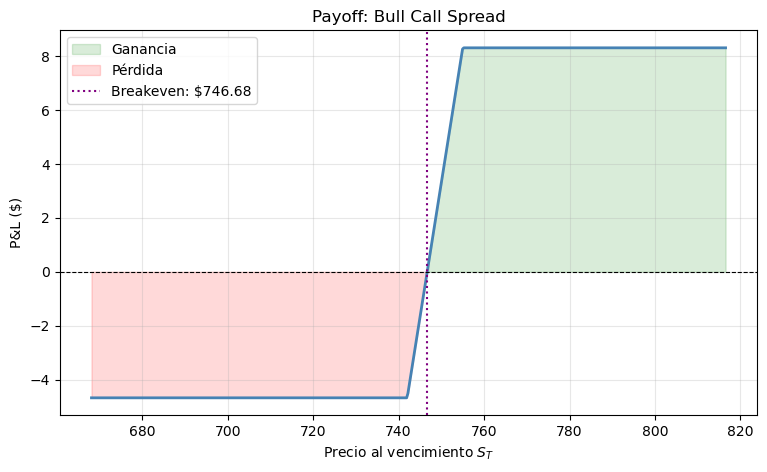

In [ ]:
# ESTRATEGIA 1: BULL CALL SPREAD
# Seleccionamos dos strikes: Uno At-The-Money (K1) y uno Out-Of-The-Money (K2)
K1 = calls.iloc[(calls['strike'] - S0).abs().argsort()[:1]]['strike'].values[0]
K2 = K1 + 10.0 # Strike superior

# Extraemos datos de los contratos
call_long = calls[calls['strike'] == K1].iloc[0]
possible_K2 = calls.loc[calls['strike'] >= K1 + 10, 'strike']
if possible_K2.empty:
    raise ValueError(f"No hay un strike disponible >= {K1 + 10}")
K2 = possible_K2.min()
call_short = calls[calls['strike'] == K2].iloc[0]

# Estructura de las patas (legs)
legs_bull_call = [
    {'tipo': 'call', 'K': K1, 'prima': call_long['mid'], 'posicion': 1, 'vol': call_long['impliedVolatility']},
    {'tipo': 'call', 'K': K2, 'prima': call_short['mid'], 'posicion': -1, 'vol': call_short['impliedVolatility']}
]

# Cálculos de rentabilidad
costo_neto = legs_bull_call[0]['prima'] - legs_bull_call[1]['prima']
max_perdida = costo_neto
max_ganancia = (K2 - K1) - costo_neto
breakeven_bc = [K1 + costo_neto]

print("--- BULL CALL SPREAD ---")
print(f"Costo neto pagado: ${costo_neto:.2f}")
print(f"Máxima Ganancia: ${max_ganancia:.2f}")
print(f"Máxima Pérdida: ${max_perdida:.2f}")
print(f"Breakeven: ${breakeven_bc[0]:.2f}\n")

# Griegas
print("Griegas Individuales y Netas:")
net_greeks_bc = {'Delta': 0, 'Gamma': 0, 'Theta': 0, 'Vega': 0}
for leg in legs_bull_call:
    g = bs_griegas(S0, leg['K'], T, r, leg['vol'], leg['tipo'])
    # Ponderar por la posición (larga=1, corta=-1)
    g_pond = {k: v * leg['posicion'] for k, v in g.items()}
    for k in net_greeks_bc:
        net_greeks_bc[k] += g_pond[k]
    print(f"  Strike {leg['K']} ({leg['tipo']} pos {leg['posicion']}): Delta: {g['Delta']:.4f}, Gamma: {g['Gamma']:.4f}, Theta: {g['Theta']:.4f}, Vega: {g['Vega']:.4f}")

print("\nGriegas Netas del Portafolio:")
print(f"Delta Neto: {net_greeks_bc['Delta']:.4f}")
print(f"Gamma Neto: {net_greeks_bc['Gamma']:.4f}")
print(f"Theta Neto: {net_greeks_bc['Theta']:.4f}")
print(f"Vega Neto:  {net_greeks_bc['Vega']:.4f}")

# Gráfica
S_range = np.linspace(S0 * 0.9, S0 * 1.1, 500)
pnl_bull_call = payoff_estrategia(S_range, legs_bull_call)
graficar_estrategia(S_range, pnl_bull_call, "Payoff: Bull Call Spread", breakeven_bc, max_ganancia, max_perdida)

Condición de mercado esperada:El Bull Call Spread tiene sentido en un entorno de mercado donde se espera un movimiento direccional alcista moderado y una volatilidad que se mantenga constante o tienda a disminuir.

Griegas:

Delta Neto Positivo: Al comprar una Call con un Strike inferior y vender otra con un Strike superior, el Delta de la Call comprada es mayor que el Delta de la Call vendida. Esto resulta en un Delta neto positivo, lo que significa matemáticamente que la estrategia genera utilidades a medida que el precio del activo subyacente ($S$) aumenta.

Vega Neto cercano a cero o negativo: La Call corta neutraliza gran parte de la exposición a la volatilidad implícita que tiene la Call larga. Si el Vega neto resulta ligeramente negativo, implica que una caída en la volatilidad implícita (típica en mercados que suben lentamente) no dañará significativamente la posición, a diferencia de una Call larga pura donde una caída en volatilidad destruye la prima.

--- IRON CONDOR ---
Crédito neto cobrado: $0.06
Máxima Ganancia: $0.06
Máxima Pérdida: $9.94
Breakevens: Inferior $704.94 | Superior $780.06

Griegas Individuales y Netas:
  Strike 695.0 (put pos 1): Delta: -0.0075, Gamma: 0.0010, Theta: -0.0416, Vega: 0.0180
  Strike 705.0 (put pos -1): Delta: -0.0138, Gamma: 0.0020, Theta: -0.0608, Vega: 0.0305
  Strike 780.0 (call pos -1): Delta: 0.0024, Gamma: 0.0006, Theta: -0.0097, Vega: 0.0064
  Strike 790.0 (call pos 1): Delta: 0.0019, Gamma: 0.0004, Theta: -0.0099, Vega: 0.0053

Griegas Netas del Portafolio:
Delta Neto: 0.0058
Gamma Neto: -0.0012
Theta Neto: 0.0190
Vega Neto:  -0.0136


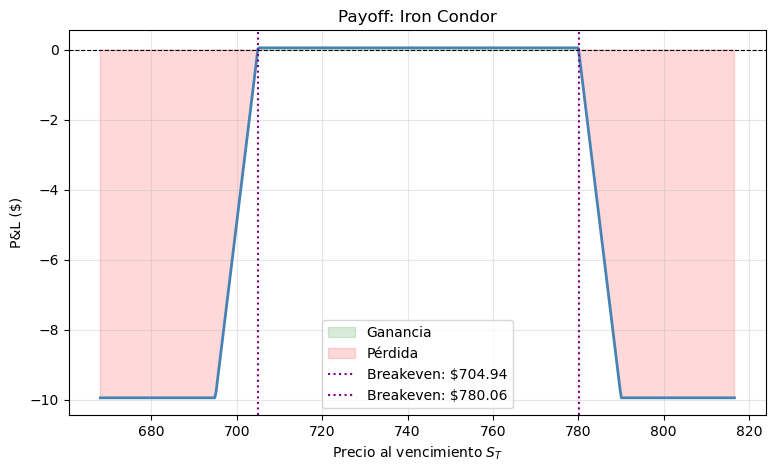

In [ ]:
# ESTRATEGIA 2: IRON CONDOR
# Buscamos un rango neutral. Vendemos opciones OTM y compramos protección más OTM.
K_put_short = calls.iloc[(calls['strike'] - (S0 * 0.95)).abs().argsort()[:1]]['strike'].values[0]
K_put_long = K_put_short - 10.0

K_call_short = calls.iloc[(calls['strike'] - (S0 * 1.05)).abs().argsort()[:1]]['strike'].values[0]
K_call_long = K_call_short + 10.0

leg_pl = puts[puts['strike'] == K_put_long].iloc[0]
leg_ps = puts[puts['strike'] == K_put_short].iloc[0]
leg_cs = calls[calls['strike'] == K_call_short].iloc[0]
leg_cl = calls[calls['strike'] == K_call_long].iloc[0]

legs_iron_condor = [
    {'tipo': 'put', 'K': K_put_long, 'prima': leg_pl['mid'], 'posicion': 1, 'vol': leg_pl['impliedVolatility']},
    {'tipo': 'put', 'K': K_put_short, 'prima': leg_ps['mid'], 'posicion': -1, 'vol': leg_ps['impliedVolatility']},
    {'tipo': 'call', 'K': K_call_short, 'prima': leg_cs['mid'], 'posicion': -1, 'vol': leg_cs['impliedVolatility']},
    {'tipo': 'call', 'K': K_call_long, 'prima': leg_cl['mid'], 'posicion': 1, 'vol': leg_cl['impliedVolatility']}
]

# Cálculos de rentabilidad (Crédito recibido)
credito_neto = (legs_iron_condor[1]['prima'] + legs_iron_condor[2]['prima']) - (legs_iron_condor[0]['prima'] + legs_iron_condor[3]['prima'])
ancho_put = K_put_short - K_put_long
ancho_call = K_call_long - K_call_short
max_perdida = max(ancho_put, ancho_call) - credito_neto
max_ganancia = credito_neto
breakeven_ic = [K_put_short - credito_neto, K_call_short + credito_neto]

print("--- IRON CONDOR ---")
print(f"Crédito neto cobrado: ${credito_neto:.2f}")
print(f"Máxima Ganancia: ${max_ganancia:.2f}")
print(f"Máxima Pérdida: ${max_perdida:.2f}")
print(f"Breakevens: Inferior ${breakeven_ic[0]:.2f} | Superior ${breakeven_ic[1]:.2f}\n")

# Griegas
print("Griegas Individuales y Netas:")
net_greeks_ic = {'Delta': 0, 'Gamma': 0, 'Theta': 0, 'Vega': 0}
for leg in legs_iron_condor:
    g = bs_griegas(S0, leg['K'], T, r, leg['vol'], leg['tipo'])
    g_pond = {k: v * leg['posicion'] for k, v in g.items()}
    for k in net_greeks_ic:
        net_greeks_ic[k] += g_pond[k]
    print(f"  Strike {leg['K']} ({leg['tipo']} pos {leg['posicion']}): Delta: {g['Delta']:.4f}, Gamma: {g['Gamma']:.4f}, Theta: {g['Theta']:.4f}, Vega: {g['Vega']:.4f}")

print("\nGriegas Netas del Portafolio:")
print(f"Delta Neto: {net_greeks_ic['Delta']:.4f}")
print(f"Gamma Neto: {net_greeks_ic['Gamma']:.4f}")
print(f"Theta Neto: {net_greeks_ic['Theta']:.4f}")
print(f"Vega Neto:  {net_greeks_ic['Vega']:.4f}")

# Gráfica
pnl_ic = payoff_estrategia(S_range, legs_iron_condor)
graficar_estrategia(S_range, pnl_ic, "Payoff: Iron Condor", breakeven_ic, max_ganancia, max_perdida)

Condición de mercado esperada:El Iron Condor es una estructura ideal para un mercado en consolidación y con expectativa de disminución en la volatilidad implícita. Esta estrategia asume que el activo no experimentará un movimiento direccional pronunciado antes del vencimiento. Tiene sentido abrirla cuando la volatilidad implícita está en percentiles históricamente altos y se espera que se normalice a la baja.

Vínculo explícito con las Griegas:

Theta Neto Positivo: Al ser una estrategia donde se cobra un crédito inicial por las primas, el portafolio se beneficia del paso del tiempo. Cada día que pasa sin que el subyacente rompa las "alas" del cóndor, la posición captura el decaimiento temporal, inyectando rentabilidad al portafolio.

Vega Neto Negativo: La posición está corta en Vega. Esto significa que la estrategia genera beneficios netos si la volatilidad implícita del mercado colapsa. Al vender las opciones más cercanas al dinero que las compradas, la sensibilidad ante una caída de la volatilidad nos favorece enormemente, acelerando la toma de utilidades incluso mucho antes del vencimiento.

### Ejercicio 12

Parámetros Seleccionados (Referencia: ETF QQQ):

$S_0$ (Precio Spot) = $440.00: Precio representativo del activo en el mercado actual.

$K$ (Precio Strike) = $440.00: Opción At-The-Money (ATM) para observar claramente el valor temporal y el impacto de las restricciones exóticas sin sesgo direccional intrínseco inicial.

$T$ (Tiempo al vencimiento) = $0.5$ años: Un horizonte de 6 meses es estándar para opciones líquidas y da suficiente tiempo para que el Movimiento Browniano Geométrico (GBM) desarrolle dispersión.

$r$ (Tasa libre de riesgo) = $0.045$ (4.5%): Tasa de interés representativa de los bonos del tesoro a corto/mediano plazo.

$\sigma$ (Volatilidad Implícita) = $0.18$ (18%): Nivel de volatilidad histórica/implícita razonable para el índice Nasdaq 100 en condiciones normales de mercado.

$B$ (Barrera Up-and-Out) = $490.00: Fijada aproximadamente un 11.3% por encima del precio Spot. Justificación: Se elige este nivel porque representa una resistencia técnica fuerte a mediano plazo. Si el activo exhibe un "rally" descontrolado que supere este nivel, el emisor de la opción con barrera cancela su riesgo.

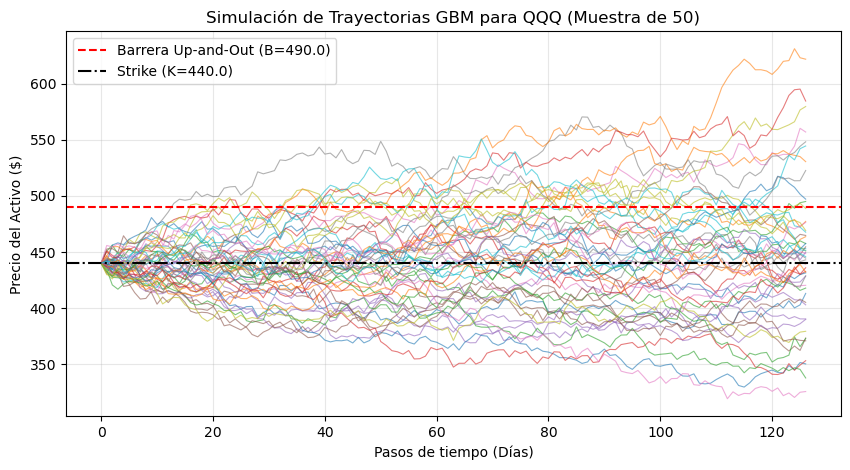

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definición de parámetros
S0 = 440.0
K = 440.0
T = 0.5
r = 0.045
sigma = 0.18
B = 490.0 

# Parámetros de Monte Carlo
M = 50000   # Número de trayectorias (rutas)
N = 126     # Pasos de tiempo (aprox. días hábiles en 6 meses)
dt = T / N

np.random.seed(42) # Semilla para reproducibilidad

# 2. Generación de Trayectorias (Movimiento Browniano Geométrico vectorizado)
Z = np.random.standard_normal((M, N))
log_returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# Matriz de trayectorias completas
S_paths = np.zeros((M, N + 1))
S_paths[:, 0] = S0
# Suma acumulada para generar la trayectoria a lo largo del tiempo
S_paths[:, 1:] = S0 * np.exp(np.cumsum(log_returns, axis=1))

# Gráfica de control (primeras 50 trayectorias para no saturar)
plt.figure(figsize=(10, 5))
plt.plot(S_paths[:50, :].T, lw=0.8, alpha=0.6)
plt.axhline(B, color='red', linestyle='--', label=f'Barrera Up-and-Out (B={B})')
plt.axhline(K, color='black', linestyle='-.', label=f'Strike (K={K})')
plt.title('Simulación de Trayectorias GBM para QQQ (Muestra de 50)')
plt.xlabel('Pasos de tiempo (Días)')
plt.ylabel('Precio del Activo ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# 3. Cálculo de Payoffs al vencimiento
factor_descuento = np.exp(-r * T)

# A) Call Europea Estándar
payoff_call_eur = np.maximum(S_paths[:, -1] - K, 0)
precio_call_eur = factor_descuento * np.mean(payoff_call_eur)

# B) Put Europea Estándar
payoff_put_eur = np.maximum(K - S_paths[:, -1], 0)
precio_put_eur = factor_descuento * np.mean(payoff_put_eur)

# C) Opción Asiática Call (Promedio Aritmético de la trayectoria)
# Se calcula el promedio a lo largo de cada fila (trayectoria completa)
S_promedio = np.mean(S_paths, axis=1)
payoff_call_asiatica = np.maximum(S_promedio - K, 0)
precio_call_asiatica = factor_descuento * np.mean(payoff_call_asiatica)

# D) Opción Call Barrera Up-and-Out
# Verifica si en ALGÚN momento de la trayectoria el precio tocó o superó la barrera
toco_barrera = np.max(S_paths, axis=1) >= B
# Si tocó la barrera, el payoff es 0. Si no, es el payoff de una Call Europea.
payoff_call_uo = np.where(toco_barrera, 0, np.maximum(S_paths[:, -1] - K, 0))
precio_call_uo = factor_descuento * np.mean(payoff_call_uo)

# 4. Tabla Comparativa
resultados = pd.DataFrame({
    'Tipo de Opción': ['Call Europea', 'Put Europea', 'Call Asiática (Promedio)', 'Call Up-and-Out (B=490)'],
    'Precio Estimado ($)': [precio_call_eur, precio_put_eur, precio_call_asiatica, precio_call_uo]
})

print("Tabla de Precios (Monte Carlo - 50,000 trayectorias):")
display(resultados.round(4))

Tabla de Precios (Monte Carlo - 50,000 trayectorias):


,Tipo de Opción,Precio Estimado ($)
0,Call Europea,27.1624
1,Put Europea,17.5409
2,Call Asiática (Promedio),15.1653
3,Call Up-and-Out (B=490),3.1739


¿Por qué las exóticas son más baratas?
La tabla muestra claramente que tanto la opción Asiática como la Up-and-Out tienen una prima menor a la Call Europea estándar.

Call Asiática: Es más barata porque el mecanismo de promediar el precio a lo largo del tiempo suaviza los picos de volatilidad. Al reducirse la volatilidad efectiva del subyacente (el promedio fluctúa menos que el precio final), la probabilidad de que la opción termine profundamente In-The-Money disminuye, lo que abarata la prima.

Call Up-and-Out: Es más barata porque el comprador asume un riesgo adicional: si el activo tiene un desempeño excepcionalmente bueno y cruza la barrera ($490), la opción muere y vale cero. El vendedor de la opción cobra menos prima precisamente porque está protegido contra pagos catastróficamente altos.

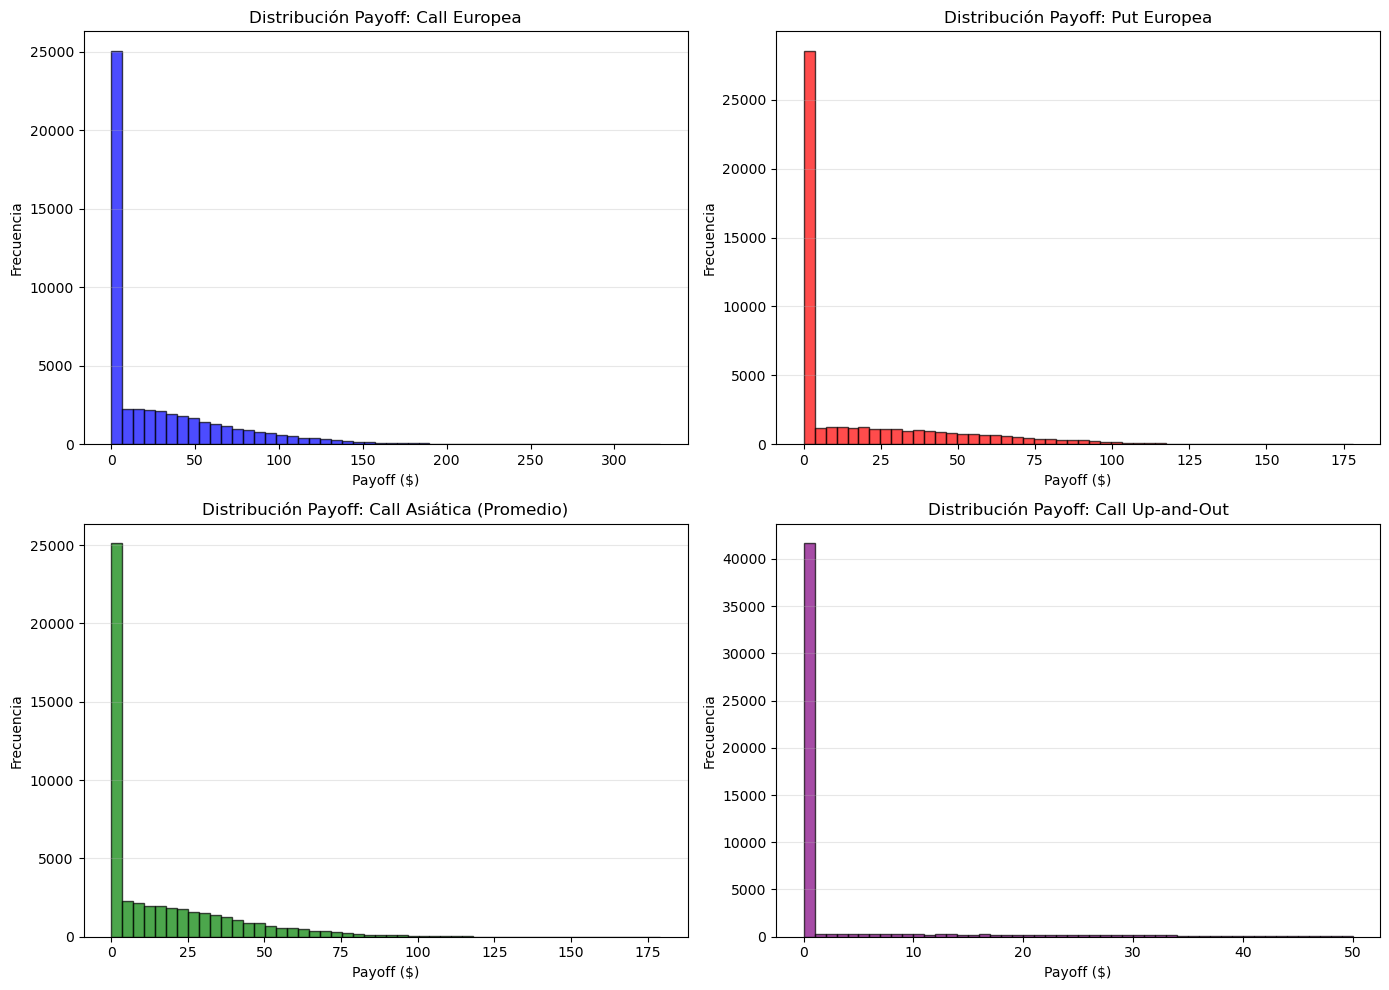

In [6]:
# 5. Gráficas de Distribución de Payoffs
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Ajuste de bins para mejor visualización excluyendo los ceros masivos temporalmente si es necesario
bins = 50

# Subplot 1: Call Europea
axs[0, 0].hist(payoff_call_eur, bins=bins, color='blue', alpha=0.7, edgecolor='black')
axs[0, 0].set_title('Distribución Payoff: Call Europea')
axs[0, 0].set_xlabel('Payoff ($)')
axs[0, 0].set_ylabel('Frecuencia')
axs[0, 0].grid(axis='y', alpha=0.3)

# Subplot 2: Put Europea
axs[0, 1].hist(payoff_put_eur, bins=bins, color='red', alpha=0.7, edgecolor='black')
axs[0, 1].set_title('Distribución Payoff: Put Europea')
axs[0, 1].set_xlabel('Payoff ($)')
axs[0, 1].set_ylabel('Frecuencia')
axs[0, 1].grid(axis='y', alpha=0.3)

# Subplot 3: Call Asiática
axs[1, 0].hist(payoff_call_asiatica, bins=bins, color='green', alpha=0.7, edgecolor='black')
axs[1, 0].set_title('Distribución Payoff: Call Asiática (Promedio)')
axs[1, 0].set_xlabel('Payoff ($)')
axs[1, 0].set_ylabel('Frecuencia')
axs[1, 0].grid(axis='y', alpha=0.3)

# Subplot 4: Call Up-and-Out
axs[1, 1].hist(payoff_call_uo, bins=bins, color='purple', alpha=0.7, edgecolor='black')
axs[1, 1].set_title('Distribución Payoff: Call Up-and-Out')
axs[1, 1].set_xlabel('Payoff ($)')
axs[1, 1].set_ylabel('Frecuencia')
axs[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Efecto del diseño del payoff sobre el precio (Evidencia Visual):

Al observar las distribuciones generadas por la simulación de Monte Carlo, las diferencias en la estructura de los pagos (payoffs) se hacen evidentes matemáticamente:

Call Asiática vs. Call Europea: En el histograma de la Call Europea, observamos una cola derecha larga, indicando que existen trayectorias donde el precio final es muy alto, generando pagos de $60, $80 o más. Por el contrario, en el histograma de la Call Asiática, la dispersión se comprime drásticamente hacia la izquierda. Puesto que el payoff depende de un promedio aritmético, los días de precios bajos "lastran" los picos de los días altos. Matemáticamente, la varianza del promedio es menor que la varianza del precio terminal, lo que recorta los pagos extremos positivos y, en consecuencia, reduce el valor presente esperado de la opción.

Call con Barrera Up-and-Out vs. Call Europea: El diseño condicional de esta opción trunca por completo la cola derecha de la distribución. Si observamos el histograma morado, existe un punto de corte duro; ningún payoff puede superar teóricamente los $50 (Barrera 490 - Strike 440). De hecho, vemos un pico masivo en cero (0) en comparación con la europea. Esto ocurre porque las trayectorias más rentables (las que superan $490) son exactamente las que "chocan" con la barrera, cancelando el contrato y arrojando un pago nulo. El vendedor de la opción transfiere este "riesgo de cola" al comprador, lo que justifica matemáticamente un precio de entrada sustancialmente inferior.